In [36]:
# ---------------------------------------------------------------------
# ******* RNN for Next Character prediction  ************
# A vanilla RNN is used for the problem of next character prediction
# using the characters from "The Time Machine" book.
# The code tries different hyperparameter configurations.
# Training uses a validation early-stopping scheme in a 30-10-60 split
# Length sequence = 20 and prediction of next character task
# Results are saved to a CSV file for tracking experiments
# ---------------------------------------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import csv
import os
from datetime import datetime

# ----------------------------
# CSV Logging Setup
# ----------------------------
CSV_COLUMNS = [
    "timestamp", "hidden_size", "num_epochs", "epochs_trained", "batch_size",
    "learning_rate", "patience", "clip_value", "dropout_rate", "optimizer",
    "activation", "weight_init", "best_val_loss", "test_accuracy", 
    "avg_epoch_time_seconds", "device", "vocab_size", "seq_length"
]

def get_csv_filename(hidden_size: int) -> str:
    """Get CSV filename for a specific hidden size."""
    return f"experiment_results_h{hidden_size}.csv"

def init_csv(hidden_size: int):
    """Initialize CSV file with headers if it doesn't exist."""
    csv_file = get_csv_filename(hidden_size)
    if not os.path.exists(csv_file):
        with open(csv_file, 'w', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=CSV_COLUMNS)
            writer.writeheader()

def log_experiment(results: dict):
    """Append experiment results to CSV file based on hidden_size."""
    hidden_size = results["hidden_size"]
    init_csv(hidden_size)  # Ensure file exists
    csv_file = get_csv_filename(hidden_size)
    with open(csv_file, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=CSV_COLUMNS)
        writer.writerow(results)

# ----------------------------
# Load text from file
# ----------------------------
file_path = "./timemachine.txt"
with open(file_path, 'r', encoding='utf-8') as f:
    raw_text = f.read()
full_text = raw_text.lower()

# ----------------------------
# Text Preprocessing: ASCII, no capitals, no punctuation, 26 letters + space + unk
# ----------------------------
allowed_chars_set = set('abcdefghijklmnopqrstuvwxyz ')
unk_token = '<unk>'

cleaned_full_text = []
for char in full_text:
    if char in allowed_chars_set:
        cleaned_full_text.append(char)
    else:
        cleaned_full_text.append(unk_token)
full_text = "".join(cleaned_full_text)

# -----------------------------------------------------
# Split percentages cannot be modified for the challenge
# Split text into train, val, test (30%, 10%, 60%)
# -----------------------------------------------------
total_length = len(full_text)
train_split_idx = int(0.3 * total_length)
val_split_idx = int(0.1 * total_length) + train_split_idx

train_text = full_text[:train_split_idx]
val_text = full_text[train_split_idx:val_split_idx]
test_text = full_text[val_split_idx:]

print(f"Total text length: {total_length}")
print(f"Train text length: {len(train_text)}")
print(f"Validation text length: {len(val_text)}")
print(f"Test text length: {len(test_text)}")

# ----------------------------
# Character mapping (re-created after cleaning)
# ----------------------------
chars = sorted(list(set(full_text)))
vocab_size = len(chars)
char2idx = {ch: i for i, ch in enumerate(chars)}
idx2char = {i: ch for i, ch in enumerate(chars)}

# ---------------------------------------------------------
# Hyperparameters that cannot be modified for the challenge
# ---------------------------------------------------------
seq_length = 20
future_steps = 1

# ---------------------------------------------------------
# Hyperparameters that should be modified for the challenge
# ---------------------------------------------------------
batch_size = 1024          # def: 32
num_epochs = 100          # def: 10
learning_rate = 0.002     # def: 0.01
patience = 2            # def: 10
hidden_sizes = [512]
clip_value = 1.0         # gradient clipping def: 1.0
dropout_rate = 0.5       # Dropout rate def: 0.5
optimizer_name = "RMSProp"  # Options: Adam, SGD, RMSprop, AdamW
activation = "relu"      # Options: relu, tanh
weight_init = "kaiming"   # Options: xavier, kaiming, orthogonal, uniform, normal
# ---------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

# Optimizaciones para GPU
if device.type == 'cuda':
    # Habilitar cuDNN benchmark para encontrar algoritmos óptimos
    torch.backends.cudnn.benchmark = True
    # Habilitar TF32 para Ampere GPUs (mejora velocidad sin perder precisión significativa)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"cuDNN benchmark: enabled")

# ----------------------------
# Dataset preparation
# ----------------------------
def create_sequences(text, seq_length, future_steps):
    X, Y = [], []
    for i in range(len(text) - seq_length - future_steps):
        seq = text[i:i+seq_length]
        target = text[i+seq_length:i+seq_length+future_steps]
        X.append([char2idx[ch] for ch in seq])
        Y.append([char2idx[ch] for ch in target])
    return np.array(X), np.array(Y)

X_train_seq, Y_train_seq = create_sequences(train_text, seq_length, future_steps)
X_val_seq, Y_val_seq = create_sequences(val_text, seq_length, future_steps)
X_test_seq, Y_test_seq = create_sequences(test_text, seq_length, future_steps)

# Mantener tensores en CPU para usar pin_memory (transferencia más rápida a GPU)
X_train = torch.tensor(X_train_seq, dtype=torch.long)
Y_train = torch.tensor(Y_train_seq, dtype=torch.long)
X_val = torch.tensor(X_val_seq, dtype=torch.long)
Y_val = torch.tensor(Y_val_seq, dtype=torch.long)
X_test_final = torch.tensor(X_test_seq, dtype=torch.long)
Y_test_final = torch.tensor(Y_test_seq, dtype=torch.long)

# Crear DataLoaders para mini-batch training con pin_memory para GPU
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, Y_train)
val_dataset = TensorDataset(X_val, Y_val)
test_dataset = TensorDataset(X_test_final, Y_test_final)

use_pin_memory = device.type == 'cuda'
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=use_pin_memory)
val_loader = DataLoader(val_dataset, batch_size=batch_size*2, shuffle=False, pin_memory=use_pin_memory)
test_loader = DataLoader(test_dataset, batch_size=batch_size*2, shuffle=False, pin_memory=use_pin_memory)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

# ----------------------------
# Vanilla RNN model
# ----------------------------
class VanillaRNN(nn.Module):
    def __init__(self, vocab_size: int, hidden_size: int, future_steps: int, 
                 dropout_rate: float = 0.0, activation: str = 'relu', 
                 weight_init: str = 'xavier'):
        super(VanillaRNN, self).__init__()
        self.hidden_size = hidden_size
        self.future_steps = future_steps
        self.weight_init = weight_init
        
        self.embedding = nn.Embedding(vocab_size, vocab_size)
        self.rnn = nn.RNN(vocab_size, hidden_size, batch_first=True, nonlinearity=activation)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_size, future_steps * vocab_size)
        self.init_weights()

    def init_weights(self):
        for name, param in self.rnn.named_parameters():
            if 'weight' in name:
                if self.weight_init == 'xavier':
                    nn.init.xavier_uniform_(param)
                elif self.weight_init == 'kaiming':
                    nn.init.kaiming_uniform_(param, nonlinearity='relu')
                elif self.weight_init == 'orthogonal':
                    nn.init.orthogonal_(param)
                elif self.weight_init == 'uniform':
                    # Small Random Values - Uniform [-0.1, 0.1]
                    nn.init.uniform_(param, -0.1, 0.1)
                elif self.weight_init == 'normal':
                    # Small Random Values - Gaussian (mean=0, std=0.1)
                    nn.init.normal_(param, mean=0.0, std=0.1)
            elif 'bias' in name:
                nn.init.zeros_(param)
        
        if self.weight_init == 'xavier':
            nn.init.xavier_uniform_(self.fc.weight)
        elif self.weight_init == 'kaiming':
            nn.init.kaiming_uniform_(self.fc.weight, nonlinearity='relu')
        elif self.weight_init == 'orthogonal':
            nn.init.orthogonal_(self.fc.weight)
        elif self.weight_init == 'uniform':
            nn.init.uniform_(self.fc.weight, -0.1, 0.1)
        elif self.weight_init == 'normal':
            nn.init.normal_(self.fc.weight, mean=0.0, std=0.1)
        nn.init.zeros_(self.fc.bias)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.rnn(x)
        out = out[:, -1, :]  # last time step
        out = self.dropout(out)
        out = self.fc(out)
        out = out.view(-1, self.future_steps, vocab_size)
        return out

def get_optimizer(name: str, parameters, lr: float):
    """Get optimizer by name."""
    optimizers = {
        'Adam': optim.Adam,
        'SGD': lambda p, lr: optim.SGD(p, lr=lr, momentum=0.9),
        'RMSprop': optim.RMSprop,
        'AdamW': optim.AdamW
    }
    return optimizers.get(name, optim.Adam)(parameters, lr=lr)

# ----------------------------
# Training loop over hidden sizes
# ----------------------------
test_accuracies = []
all_results = []

print(f"\n{'='*60}")
print(f"Starting experiments - Results will be saved to experiment_results_h<size>.csv")
print(f"{'='*60}")

for hidden_size in hidden_sizes:
    print(f"\n{'─'*40}")
    print(f"Training RNN with hidden size: {hidden_size}")
    print(f"{'─'*40}")
    
    # Start timing
    start_time = time.time()
    
    rnn = VanillaRNN(
        vocab_size, hidden_size, future_steps, 
        dropout_rate=dropout_rate, activation=activation, weight_init=weight_init
    ).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = get_optimizer(optimizer_name, rnn.parameters(), learning_rate)

    best_val_loss = float('inf')
    patience_counter = 0
    epochs_trained = 0

    for epoch in range(num_epochs):
        epochs_trained = epoch + 1
        
        # Training con mini-batches
        rnn.train()
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device, non_blocking=True), batch_y.to(device, non_blocking=True)
            optimizer.zero_grad()
            output = rnn(batch_x)
            loss = criterion(output[:, 0, :], batch_y[:, 0])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(rnn.parameters(), clip_value)
            optimizer.step()

        # Validation con mini-batches
        rnn.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device, non_blocking=True), batch_y.to(device, non_blocking=True)
                val_output = rnn(batch_x)
                val_loss += criterion(val_output[:, 0, :], batch_y[:, 0]).item()
        val_loss /= len(val_loader)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(rnn.state_dict(), f"best_rnn_TimeMachine_{hidden_size}.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    # End timing - calcular tiempo medio por época
    total_training_time = time.time() - start_time
    avg_epoch_time = total_training_time / epochs_trained

    # Final Test accuracy con mini-batches
    rnn.load_state_dict(torch.load(f"best_rnn_TimeMachine_{hidden_size}.pth", weights_only=True))
    rnn.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device, non_blocking=True), batch_y.to(device, non_blocking=True)
            output = rnn(batch_x)
            preds = output[:, 0, :].argmax(dim=1)
            correct += (preds == batch_y[:, 0]).sum().item()
            total += batch_y.size(0)
    acc = correct / total
    test_accuracies.append(acc)

    print(f"Hidden size {hidden_size}:")
    print(f"  - Epochs trained: {epochs_trained}")
    print(f"  - Best val loss: {best_val_loss:.4f}")
    print(f"  - Test accuracy: {acc*100:.2f}%")
    print(f"  - Avg time per epoch: {avg_epoch_time:.2f}s")

    # Log results to CSV
    experiment_results = {
        "timestamp": datetime.now().isoformat(),
        "hidden_size": hidden_size,
        "num_epochs": num_epochs,
        "epochs_trained": epochs_trained,
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "patience": patience,
        "clip_value": clip_value,
        "dropout_rate": dropout_rate,
        "optimizer": optimizer_name,
        "activation": activation,
        "weight_init": weight_init,
        "best_val_loss": f"{float(best_val_loss):.6f}",
        "test_accuracy": f"{acc:.6f}",
        "avg_epoch_time_seconds": f"{avg_epoch_time:.3f}",
        "device": str(device),
        "vocab_size": vocab_size,
        "seq_length": seq_length
    }
    log_experiment(experiment_results)
    all_results.append(experiment_results)

print(f"\n{'='*60}")
print(f"All experiments completed! Results saved to experiment_results_h<size>.csv files")
print(f"{'='*60}")

# Display summary table
print("\nSummary of experiments:")
print("-" * 85)
print(f"{'Hidden':>8} | {'Epochs':>6} | {'Val Loss':>10} | {'Accuracy':>10} | {'Avg Epoch (s)':>13}")
print("-" * 85)
for r in all_results:
    print(f"{r['hidden_size']:>8} | {r['epochs_trained']:>6} | {r['best_val_loss']:>10} | {float(r['test_accuracy'])*100:>9.2f}% | {r['avg_epoch_time_seconds']:>13}")

Total text length: 214451
Train text length: 64335
Validation text length: 21445
Test text length: 128671

Using device: cuda
GPU: Tesla T4
cuDNN benchmark: enabled


Train batches: 63, Val batches: 11, Test batches: 63

Starting experiments - Results will be saved to experiment_results_h<size>.csv

────────────────────────────────────────
Training RNN with hidden size: 512
────────────────────────────────────────
Early stopping at epoch 12
Hidden size 512:
  - Epochs trained: 12
  - Best val loss: 1.3956
  - Test accuracy: 57.90%
  - Avg time per epoch: 1.09s

All experiments completed! Results saved to experiment_results_h<size>.csv files

Summary of experiments:
-------------------------------------------------------------------------------------
  Hidden | Epochs |   Val Loss |   Accuracy | Avg Epoch (s)
-------------------------------------------------------------------------------------
     512 |     12 |   1.395645 |     57.90% |         1.087


FINAL EXPERIMENT: 20 Independent Runs
Hyperparameters (from Cell 0):
  Hidden size: 512
  Batch size: 1024
  Learning rate: 0.002
  Optimizer: RMSProp
  Activation: relu
  Weight init: kaiming
  Dropout: 0.5
  Patience: 2
  Clip value: 1.0
  Num epochs: 100

Run 1/20 - Epochs: 12, Test Acc: 58.10%
Run 2/20 - Epochs: 11, Test Acc: 57.96%
Run 3/20 - Epochs: 12, Test Acc: 58.21%
Run 4/20 - Epochs: 13, Test Acc: 58.28%
Run 5/20 - Epochs: 12, Test Acc: 58.11%
Run 6/20 - Epochs: 12, Test Acc: 57.93%
Run 7/20 - Epochs: 12, Test Acc: 57.96%
Run 8/20 - Epochs: 13, Test Acc: 57.91%
Run 9/20 - Epochs: 11, Test Acc: 58.07%
Run 10/20 - Epochs: 11, Test Acc: 57.88%
Run 11/20 - Epochs: 12, Test Acc: 57.97%
Run 12/20 - Epochs: 12, Test Acc: 58.21%
Run 13/20 - Epochs: 12, Test Acc: 57.87%
Run 14/20 - Epochs: 10, Test Acc: 57.61%
Run 15/20 - Epochs: 11, Test Acc: 57.98%
Run 16/20 - Epochs: 11, Test Acc: 57.97%
Run 17/20 - Epochs: 11, Test Acc: 57.92%
Run 18/20 - Epochs: 11, Test Acc: 58.16%
Run 19/20 - 

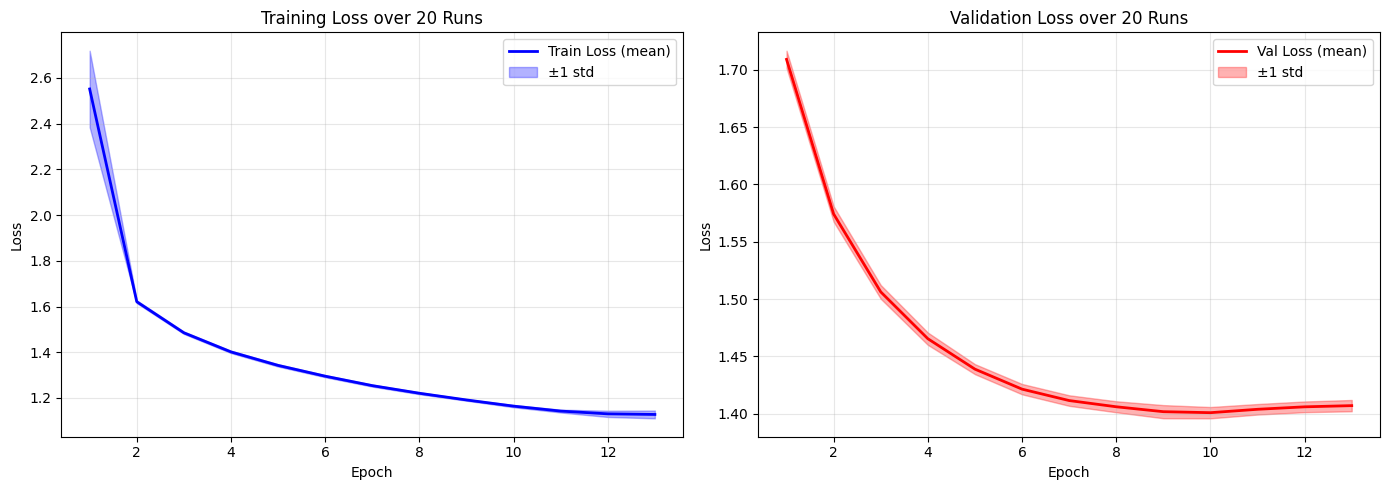

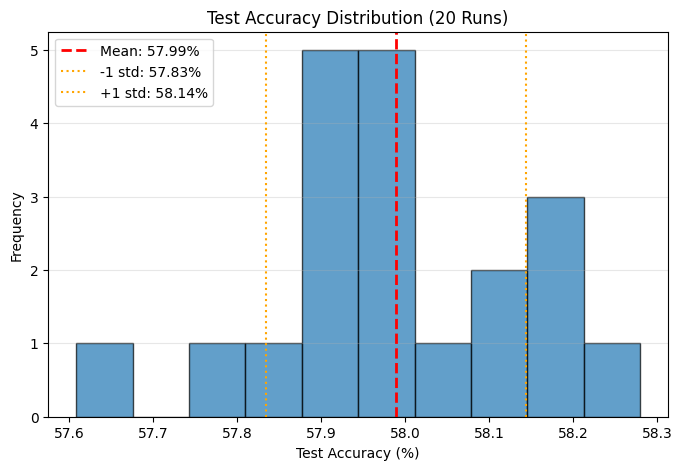


📊 Plots saved: 'final_learning_curves.png' and 'final_accuracy_distribution.png'


In [37]:
# =====================================================================
# FINAL EXPERIMENT: 20 Independent Runs
# =====================================================================
# This cell runs 20 independent training runs with different random
# initializations to report average learning curves with std deviation
# and final accuracy with std deviation.
# Uses the hyperparameters defined in Cell 0.
# =====================================================================

import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Use hyperparameters from Cell 0 (must run Cell 0 first!)
# ---------------------------------------------------------
FINAL_HIDDEN_SIZE = hidden_sizes[0]
NUM_RUNS = 20
# ---------------------------------------------------------

print(f"{'='*70}")
print(f"FINAL EXPERIMENT: {NUM_RUNS} Independent Runs")
print(f"{'='*70}")
print(f"Hyperparameters (from Cell 0):")
print(f"  Hidden size: {FINAL_HIDDEN_SIZE}")
print(f"  Batch size: {batch_size}")
print(f"  Learning rate: {learning_rate}")
print(f"  Optimizer: {optimizer_name}")
print(f"  Activation: {activation}")
print(f"  Weight init: {weight_init}")
print(f"  Dropout: {dropout_rate}")
print(f"  Patience: {patience}")
print(f"  Clip value: {clip_value}")
print(f"  Num epochs: {num_epochs}")
print(f"{'='*70}\n")

# Usar los DataLoaders ya creados en Cell 0
final_train_loader = train_loader
final_val_loader = val_loader
final_test_loader = test_loader

# Storage for all runs
all_train_losses = []  # List of lists: each run's training loss per epoch
all_val_losses = []    # List of lists: each run's validation loss per epoch
all_test_accuracies = []
all_epochs_trained = []

for run in range(NUM_RUNS):
    print(f"Run {run+1}/{NUM_RUNS}", end=" ")
    
    # Set different random seed for each run (for reproducibility if needed)
    torch.manual_seed(run * 42)
    if device.type == 'cuda':
        torch.cuda.manual_seed(run * 42)
    
    # Create fresh model with new random initialization
    model = VanillaRNN(
        vocab_size, FINAL_HIDDEN_SIZE, future_steps,
        dropout_rate=dropout_rate, 
        activation=activation, 
        weight_init=weight_init
    ).to(device)
    
    criterion = nn.CrossEntropyLoss()
    opt = get_optimizer(optimizer_name, model.parameters(), learning_rate)
    
    best_val_loss = float('inf')
    patience_counter = 0
    
    run_train_losses = []
    run_val_losses = []
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        epoch_train_loss = 0.0
        num_batches = 0
        for batch_x, batch_y in final_train_loader:
            batch_x, batch_y = batch_x.to(device, non_blocking=True), batch_y.to(device, non_blocking=True)
            opt.zero_grad()
            output = model(batch_x)
            loss = criterion(output[:, 0, :], batch_y[:, 0])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)
            opt.step()
            epoch_train_loss += loss.item()
            num_batches += 1
        epoch_train_loss /= num_batches
        run_train_losses.append(epoch_train_loss)
        
        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_x, batch_y in final_val_loader:
                batch_x, batch_y = batch_x.to(device, non_blocking=True), batch_y.to(device, non_blocking=True)
                val_output = model(batch_x)
                val_loss += criterion(val_output[:, 0, :], batch_y[:, 0]).item()
        val_loss /= len(final_val_loader)
        run_val_losses.append(val_loss)
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f"final_best_model_run{run}.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
    
    epochs_trained = len(run_train_losses)
    all_epochs_trained.append(epochs_trained)
    all_train_losses.append(run_train_losses)
    all_val_losses.append(run_val_losses)
    
    # Test accuracy
    model.load_state_dict(torch.load(f"final_best_model_run{run}.pth", weights_only=True))
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_x, batch_y in final_test_loader:
            batch_x, batch_y = batch_x.to(device, non_blocking=True), batch_y.to(device, non_blocking=True)
            output = model(batch_x)
            preds = output[:, 0, :].argmax(dim=1)
            correct += (preds == batch_y[:, 0]).sum().item()
            total += batch_y.size(0)
    acc = correct / total
    all_test_accuracies.append(acc)
    
    print(f"- Epochs: {epochs_trained}, Test Acc: {acc*100:.2f}%")
    
    # Clean up temporary model file
    os.remove(f"final_best_model_run{run}.pth")

# =====================================================================
# RESULTS SUMMARY
# =====================================================================
print(f"\n{'='*70}")
print("FINAL RESULTS SUMMARY")
print(f"{'='*70}")

accuracies = np.array(all_test_accuracies)
mean_acc = accuracies.mean()
std_acc = accuracies.std()

print(f"\nTest Accuracy over {NUM_RUNS} runs:")
print(f"  Mean: {mean_acc*100:.2f}%")
print(f"  Std:  {std_acc*100:.2f}%")
print(f"  Min:  {accuracies.min()*100:.2f}%")
print(f"  Max:  {accuracies.max()*100:.2f}%")

print(f"\nEpochs trained:")
print(f"  Mean: {np.mean(all_epochs_trained):.1f}")
print(f"  Std:  {np.std(all_epochs_trained):.1f}")

# =====================================================================
# LEARNING CURVES WITH STD DEVIATION
# =====================================================================
# Pad all runs to the same length (max epochs)
max_epochs = max(len(losses) for losses in all_train_losses)

def pad_losses(losses_list, max_len):
    """Pad each run's losses to max_len using the last value."""
    padded = []
    for losses in losses_list:
        if len(losses) < max_len:
            # Pad with the last value
            padded.append(losses + [losses[-1]] * (max_len - len(losses)))
        else:
            padded.append(losses)
    return np.array(padded)

train_losses_padded = pad_losses(all_train_losses, max_epochs)
val_losses_padded = pad_losses(all_val_losses, max_epochs)

# Calculate mean and std
train_mean = train_losses_padded.mean(axis=0)
train_std = train_losses_padded.std(axis=0)
val_mean = val_losses_padded.mean(axis=0)
val_std = val_losses_padded.std(axis=0)

epochs_range = np.arange(1, max_epochs + 1)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training Loss
ax1 = axes[0]
ax1.plot(epochs_range, train_mean, 'b-', label='Train Loss (mean)', linewidth=2)
ax1.fill_between(epochs_range, train_mean - train_std, train_mean + train_std, 
                  alpha=0.3, color='blue', label='±1 std')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title(f'Training Loss over {NUM_RUNS} Runs')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Validation Loss
ax2 = axes[1]
ax2.plot(epochs_range, val_mean, 'r-', label='Val Loss (mean)', linewidth=2)
ax2.fill_between(epochs_range, val_mean - val_std, val_mean + val_std, 
                  alpha=0.3, color='red', label='±1 std')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title(f'Validation Loss over {NUM_RUNS} Runs')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('final_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Accuracy distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(accuracies * 100, bins=10, edgecolor='black', alpha=0.7)
ax.axvline(mean_acc * 100, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_acc*100:.2f}%')
ax.axvline((mean_acc - std_acc) * 100, color='orange', linestyle=':', linewidth=1.5, label=f'-1 std: {(mean_acc-std_acc)*100:.2f}%')
ax.axvline((mean_acc + std_acc) * 100, color='orange', linestyle=':', linewidth=1.5, label=f'+1 std: {(mean_acc+std_acc)*100:.2f}%')
ax.set_xlabel('Test Accuracy (%)')
ax.set_ylabel('Frequency')
ax.set_title(f'Test Accuracy Distribution ({NUM_RUNS} Runs)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.savefig('final_accuracy_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Plots saved: 'final_learning_curves.png' and 'final_accuracy_distribution.png'")